In [8]:
# Import Libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [9]:
# Load Dataset
train_path = "../dataset/Archive-3/train"
test_path = "../dataset/Archive-3/test"

In [10]:
print(type(train_path))
print(train_path)

<class 'str'>
../dataset/Archive-3/train


In [11]:
import tensorflow as tf

model = tf.keras.models.load_model("best_model.keras")

In [12]:
test_path = r"../dataset/Archive-3/test"

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 7178 files belonging to 7 classes.


In [13]:
# Evaluate Model Accuracy
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)



225/225 [==============================] - 148s 550ms/step - loss: 1.5982 - accuracy: 0.3909
Test Loss: 1.598167061805725
Test Accuracy: 0.3909166753292084


In [14]:
# Generate Predictions
predictions = model.predict(test_dataset)

225/225 [==============================] - 115s 460ms/step


In [15]:
predicted_labels = np.argmax(predictions, axis=1)

In [16]:
# Get True Labels
true_labels = np.concatenate(
    [labels.numpy() for images, labels in test_dataset],
    axis=0
)

In [19]:
# Generate Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)

print(cm)

[[  46    0   59  369  145  274   65]
 [   4    0    5   45   22   31    4]
 [  16    0   70  427  124  254  133]
 [   9    0   20 1365  110  194   76]
 [   4    0   29  530  407  226   37]
 [  13    0   28  489  191  488   38]
 [   5    0   64  213   76   43  430]]


In [17]:
# Get class names from your dataset
class_names = test_dataset.class_names

print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [18]:
train_path = r"../dataset/Archive-3/train"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=train_path,
    image_size=(224,224),
    batch_size=32
)

Found 28709 files belonging to 7 classes.


In [20]:
class_names = train_dataset.class_names

print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [21]:
#  Define class names for the confusin matrix
class_names = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

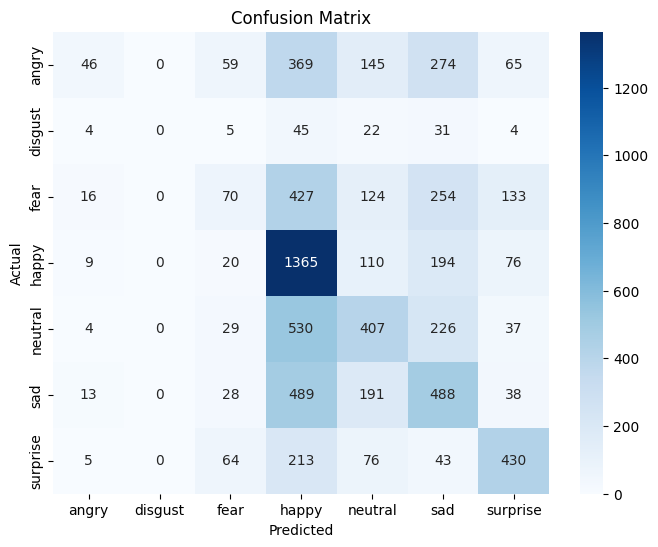

In [22]:
# plot confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [23]:
print(type(train_dataset))
print(type(test_dataset))

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


In [24]:
# Classification Report
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

       angry       0.47      0.05      0.09       958
     disgust       0.00      0.00      0.00       111
        fear       0.25      0.07      0.11      1024
       happy       0.40      0.77      0.52      1774
     neutral       0.38      0.33      0.35      1233
         sad       0.32      0.39      0.35      1247
    surprise       0.55      0.52      0.53       831

    accuracy                           0.39      7178
   macro avg       0.34      0.30      0.28      7178
weighted avg       0.38      0.39      0.34      7178



c:\Users\avani\Documents\DeepFER\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\avani\Documents\DeepFER\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\avani\Documents\DeepFER\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

In [23]:
# This report includes:

# 1.Precision: Out of all images predicted as a class, how many were correct?
# 2.Recall: Out of all actual images of a class, how many were found?
# 3.F1-score: Balance between precision and recall.
# 4.Support: Number of samples for each class.

In [3]:
# checkpoints
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [26]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    callbacks=[
        checkpoint,
        early_stop
    ]
)


Epoch 1/20
898/898 [==============================] - ETA: 0s - loss: 1.6196 - accuracy: 0.3430
Epoch 1: val_accuracy did not improve from 0.38924
898/898 [==============================] - 544s 603ms/step - loss: 1.6196 - accuracy: 0.3430 - val_loss: 1.5984 - val_accuracy: 0.3702
Epoch 2/20
898/898 [==============================] - ETA: 0s - loss: 1.6192 - accuracy: 0.3388
Epoch 2: val_accuracy did not improve from 0.38924
898/898 [==============================] - 565s 627ms/step - loss: 1.6192 - accuracy: 0.3388 - val_loss: 1.6059 - val_accuracy: 0.3639
Epoch 3/20
898/898 [==============================] - ETA: 0s - loss: 1.6178 - accuracy: 0.3384
Epoch 3: val_accuracy did not improve from 0.38924
898/898 [==============================] - 592s 660ms/step - loss: 1.6178 - accuracy: 0.3384 - val_loss: 1.5832 - val_accuracy: 0.3795
Epoch 4/20
898/898 [==============================] - ETA: 0s - loss: 1.6138 - accuracy: 0.3413
Epoch 4: val_accuracy did not improve from 0.38924
898/898

In [27]:
import matplotlib.pyplot as plt

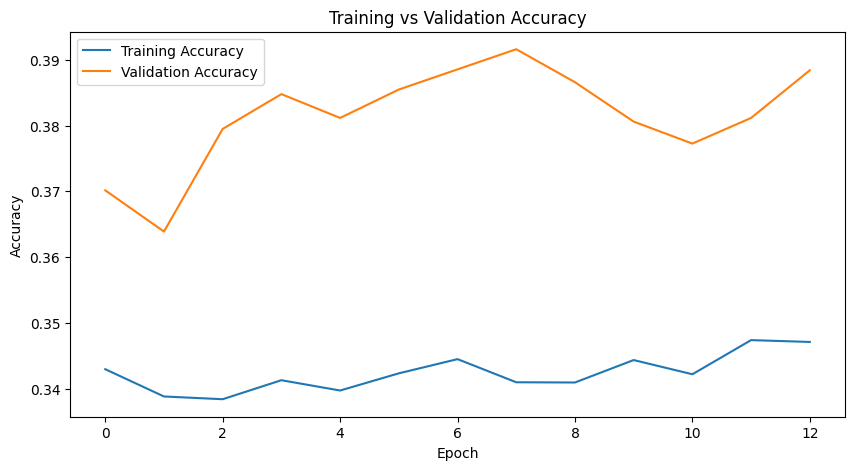

In [28]:
# Plot Training & Validation Accuracy
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

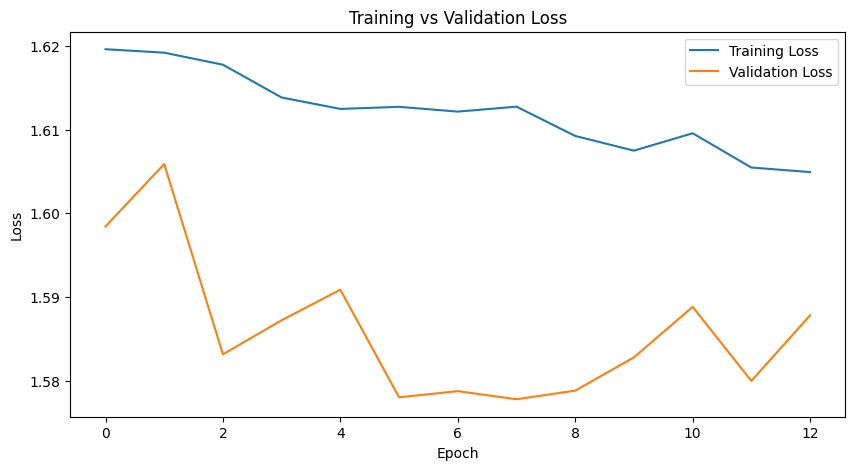

In [29]:
# Plot Training & Validation Loss graph
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [30]:
# Save your training history after training:
import pickle

with open("training_history.pkl", "wb") as file:
    pickle.dump(history.history, file)

In [31]:
with open("training_history.pkl", "rb") as file:
    history_data = pickle.load(file)

In [32]:
model.save("emotion_detection_model.keras")